<a href="https://colab.research.google.com/github/pixi2102/iad-intro-ds/blob/master/_hw06_texts_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Интеллектуальный анализ данных – весна 2025
# Домашнее задание 6: классификация текстов

Правила:



*   Домашнее задание оценивается в 10 баллов.
*   Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.
*  Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.
*  Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.
*  Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.
* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

В этом домашнем задании вам предстоит построить классификатор текстов.

Будем предсказывать эмоциональную окраску твиттов о коронавирусе.



In [1]:
import numpy as np
import pandas as pd
from typing import  List
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation

In [2]:

df = pd.read_csv('/content/tweets_coronavirus.csv', encoding='latin-1')
df.sample(4)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
18575,26411,71363,Hyderabad,25-03-2020,@AmitShah @MoHFW_INDIA @Vkpandia sir I m a ret...,Negative
2187,6463,51415,"Long Island, NY",18-03-2020,"As a side effect of #CoronaVirus, you may have...",Positive
7714,13174,58126,NaN,20-03-2020,@AsteadWesley You been to the clusterfuck at t...,Negative
10543,16588,61540,"San Juan, Puerto Rico",21-03-2020,1 Gov Wanda Vazquez said Saturday that this is...,Positive


Для каждого твитта указано:


*   UserName - имя пользователя, заменено на целое число для анонимности
*   ScreenName - отображающееся имя пользователя, заменено на целое число для анонимности
*   Location - местоположение
*   TweetAt - дата создания твитта
*   OriginalTweet - текст твитта
*   Sentiment - эмоциональная окраска твитта (целевая переменная)



## Задание 1 Подготовка (0.5 балла)

Целевая переменная находится в колонке `Sentiment`.  Преобразуйте ее таким образом, чтобы она стала бинарной: 1 - если у твитта положительная или очень положительная эмоциональная окраска и 0 - если отрицательная или очень отрицательная.

In [3]:
df['Sentiment'].unique()

array(['Positive', 'Extremely Negative', 'Negative', 'Extremely Positive'],
      dtype=object)

In [4]:
def convert(word):
    if word in ['Positive', 'Extremely Positive']:
        return 1
    elif word in ['Negative', 'Extremely Negative']:
        return 0
df['Sentiment'] = df['Sentiment'].apply(convert)# -- YOUR CODE HERE --

Сбалансированы ли классы?

In [5]:
df['Sentiment'].value_counts()
# -- YOUR CODE HERE --

,count
Sentiment,
1,18046
0,15398


**Ответ:** Видим, что 18046  и 15398 отличаются меньше, чем на 20%, то есть можем считать классы сбалансированными.

Выведете на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их строкой 'Unknown'.

In [6]:
df.isnull().sum()# -- YOUR CODE HERE --

,0
UserName,0
ScreenName,0
Location,7049
TweetAt,0
OriginalTweet,0
Sentiment,0


In [7]:
df.fillna('Unknown', inplace=True)

Разделите данные на обучающие и тестовые в соотношении 7 : 3 и укажите `random_state=0`

In [8]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df,test_size=0.3,random_state=0)# -- YOUR CODE HERE --

## Задание 2 Токенизация (3 балла)

Постройте словарь на основе обучающей выборки и посчитайте количество встреч каждого токена с использованием самой простой токенизации - деления текстов по пробельным символам и приведения токенов в нижний регистр.

In [9]:
from collections import Counter
def tokenize(text):
    return text.lower().split()
token_counter = Counter()

for text in train['OriginalTweet']:
    tokens = tokenize(text)
    token_counter.update(tokens)


Какой размер словаря получился?

In [10]:
len(token_counter)# -- YOUR CODE HERE --

79755

Выведите 10 самых популярных токенов с количеством встреч каждого из них. Объясните, почему именно эти токены в топе.

In [11]:
for token, count in token_counter.most_common(10):
    print(token, count)# -- YOUR CODE HERE --

the 26815
to 23373
and 14684
of 13012
a 11737
in 11198
for 8566
#coronavirus 8223
is 7383
are 7050


**Ответ:** Видим, что среди самых популярных токенов есть предлоги (to,in, for, и тд), союзы (and) и артикли (the, a). Это логично, так как без них почти невозможно построить предложение. Также среди популярных токенов есть глаголы связки (are, is) -- это одни из самых популярных глаголов в английском. Особенно выделяется токен #coronovirus -- думаю, это связано с выборкой твитов, возможно они брались в 2019-2022 году, когда тема пандемии была очень актуальна.

Удалите стоп-слова из словаря и выведите новый топ-10 токенов (и количество встреч) по популярности.  Что можно сказать  о нем?

In [12]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
def tokenize(text):
    tokens = text.lower().split()
    return [token for token in tokens if token not in stop_words]
token_counter = Counter()
for text in train['OriginalTweet']:
    token_counter.update(tokenize(text))
for token, count in token_counter.most_common(10):
    print(token, count)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#coronavirus 8223
prices 3891
food 3820
grocery 3469
supermarket 3288
people 3175
covid-19 3173
store 3155
#covid19 2471
&amp; 2314


**Ответ:**  Видим, что после того, как мы удалили стоп-слова, содержащие предлоги/союзы/артикли/ и тд, среди самых популярных слов остались в основном существительные, которые часто используются в повседневной жизни (люди, супермаркет, еда, магазин и так далее). Также много слов с участием коронавируса, так как это было острой темой.

Также выведите 20 самых непопулярных слов (если самых непопулярных слов больше, выведите любые 20 из них) Почему эти токены непопулярны, требуется ли как-то дополнительно работать с ними?

In [13]:
for token, count in token_counter.most_common()[-20:]:
    print(f"{token}: {count}")# -- YOUR CODE HERE --

skellig: 1
coast!: 1
closer!): 1
@skelligsix18: 1
#skelligcoast2kms: 1
#southkerry: 1
https://t.co/zjcl195vqs: 1
@srinivasiyc: 1
https://t.co/iaek4fwsgz: 1
premiership: 1
non-playing: 1
subsidise: 1
playersãâ: 1
renewing: 1
wage!: 1
flew: 1
nothing...: 1
@torontopearson: 1
@680news: 1
https://t.co/7j2y3rsld9: 1


**Ответ:** Среди непопулярных токенов есть ссылки на сайты, слова с опечатками, никнеймы и редкие термины (например subsidise). Может быть было бы полезно удалить токены, начинающиеся с @ или https:// (никнеймы и ссылки на сайты), а также токены содержащие необычные символы (вроде playersãâ, можно предположить, что это сбои или опечатки), так как эти токены, скорее всего, не несут никакой смысловой окраски.



Теперь воспользуемся токенайзером получше - TweetTokenizer из библиотеки nltk. Примените его и посмотрите на топ-10 популярных слов. Чем он отличается от топа, который получался раньше? Почему?

In [14]:
from nltk.tokenize import TweetTokenizer
def tokenize(text):
    tokenizer = TweetTokenizer()
    return tokenizer.tokenize(text.lower())

token_counter = Counter()
for text in train['OriginalTweet']:
    token_counter.update(tokenize(text))
for token, count in token_counter.most_common(10):
    print(f"{token}: {count}")

the: 26993
.: 24118
to: 23478
,: 17571
and: 14825
of: 13044
a: 11891
in: 11348
?: 9524
#coronavirus: 8808


**Ответ:** Здесь помимо артиклей, союзов и предлогов вывелись также знаки препинания, так как TweetTokenizer не удаляет ни стоп-слова, ни знаки препинания. (понятно, что знаки применания используются чаще всего для построения предложений).

Удалите из словаря стоп-слова и пунктуацию, посмотрите на новый топ-10 слов с количеством встреч, есть ли теперь в нем что-то не похожее на слова?

In [15]:
from string import punctuation
def tokenize(text):
    tokenizer = TweetTokenizer()
    tokens = tokenizer.tokenize(text.lower())
    return [token for token in tokens if token not in stop_words and token not in punctuation]

token_counter = Counter()
for text in train['OriginalTweet']:
    token_counter.update(tokenize(text))
for token, count in token_counter.most_common(10):
    print(f"{token}: {count}")
# -- YOUR CODE HERE --

#coronavirus: 8808
â: 7415
: 7311
19: 7167
covid: 6253
prices: 4601
: 4372
food: 4367
store: 3877
supermarket: 3805


**Ответ:** Помимо популярных слов вроде food, prices, etc также есть символ в виде вопросительного знака в квадрате (скорее всего, это два неотображаемых символа) и буква â.

Скорее всего в некоторых топах были неотображаемые символы или отдельные буквы не латинского алфавита. Уберем их: удалите из словаря токены из одного символа, позиция которого в таблице Unicode 128 и более (`ord(x) >= 128`)

Выведите топ-10 самых популярных и топ-20 непопулярных слов. Чем полученные топы отличаются от итоговых топов, полученных при использовании токенизации по пробелам? Что теперь лучше, а что хуже?

In [16]:
def tokenize(text):
    tokenizer = TweetTokenizer()
    tokens = tokenizer.tokenize(text.lower())
    return [token for token in tokens if token not in stop_words and token not in punctuation
            and (len(token) > 1 or ord(token) < 128)]

token_counter = Counter()
for text in train['OriginalTweet']:
    token_counter.update(tokenize(text))
print('Топ популярных:')
for token, count in token_counter.most_common(10):
    print(f"{token}: {count}")
print('Топ непопулярных:')
for token, count in token_counter.most_common()[-20:]:
    print(f"{token}: {count}")# -- YOUR CODE HERE --

Топ популярных:
#coronavirus: 8808
19: 7167
covid: 6253
prices: 4601
food: 4367
store: 3877
supermarket: 3805
grocery: 3523
people: 3463
#covid19: 2589
Топ непопулярных:
https://t.co/lw1r0rm7xs: 1
https://t.co/5cbliqzx7l: 1
now.when: 1
milion: 1
skellig: 1
@skelligsix18: 1
#skelligcoast2kms: 1
#southkerry: 1
https://t.co/zjcl195vqs: 1
@srinivasiyc: 1
https://t.co/iaek4fwsgz: 1
premiership: 1
non-playing: 1
subsidise: 1
playersã: 1
renewing: 1
flew: 1
@torontopearson: 1
@680news: 1
https://t.co/7j2y3rsld9: 1


**Ответ:** Среди непопулярных токенов у нас по прежнему остались сайты и никнеймы, зато больше нет знаков препинания и неотображаемых символов. Популярные топы очень похожи, однако в обоих случаях видим, что иногда встречается слово и хэштег с тем же словом (как coronavirus и #coronavirus), поэтому, наверное хэштеги следует рассмотреть отдельно.

Выведите топ-10 популярных хештегов (токены, первые символы которых - #) с количеством встреч. Что можно сказать о них?

In [17]:
def tokenize(text):
    tokenizer = TweetTokenizer()
    tokens = tokenizer.tokenize(text.lower())
    return [token for token in tokens if token.startswith('#') and
            token not in stop_words and
            token not in punctuation]

token_counter = Counter()
for text in train['OriginalTweet']:
    token_counter.update(tokenize(text))
for hashtag, count in  token_counter.most_common(10):
    print(f"{hashtag}: {count}")# -- YOUR CODE HERE --

#coronavirus: 8808
#covid19: 2589
#covid_19: 1734
#covid2019: 946
#toiletpaper: 744
#covid: 641
#socialdistancing: 465
#coronacrisis: 448
#pandemic: 257
#coronaviruspandemic: 249


**Ответ:** Все самые популярные хэштеги связаны с темой пандемии (коронавирус, ковид, туалетная бумага и так далее). Это подтверждает наше предположение о том, что твиты были взяты в период 2019-2022 года.

То же самое проделайте для ссылок на сайт https://t.co Сравнима ли популярность ссылок с популярностью хештегов? Будет ли информация о ссылке на конкретную страницу полезна?

In [18]:
def tokenize(text):
    tokenizer = TweetTokenizer()
    tokens = tokenizer.tokenize(text.lower())
    return [token for token in tokens if token.startswith('https://t.co') and
            token not in stop_words and
            token not in punctuation]

token_counter = Counter()
for text in train['OriginalTweet']:
    token_counter.update(tokenize(text))
for h, count in  token_counter.most_common(10):
    print(f"{h}: {count}")# -- YOUR CODE HERE --

https://t.co/oxa7swtond: 5
https://t.co/gp3eusapl8: 4
https://t.co/deftrui1pfãâ: 3
https://t.co/wrlhyzizaa: 3
https://t.co/kuwipf1kqw: 3
https://t.co/zjnrx6dkkn: 3
https://t.co/3gbbdpdjat: 3
https://t.co/e2znxajpre: 3
https://t.co/catkegayoy: 3
https://t.co/g63rp042ho: 3


**Ответ:** Очевидно несравнима -- у хэштегов повторений по несколько сотен, в то время как у ссылок не более 5 штук. Это логично, так как люди используют хэштеги, чтобы продвинуть свой твит и отнести его к определнной теме, а ссылки используются значительно реже.

Используем опыт предыдущих экспериментов и напишем собственный токенайзер, улучшив TweetTokenizer. Функция tokenize должна:



*   Привести текст в нижний регистр
*   Применить TweetTokenizer для  выделения токенов
*   Удалить стоп-слова, пунктуацию, токены из одного символа с позицией в таблице Unicode 128 и более,  ссылки на t.co



In [19]:
def custom_tokenizer(text):
  text = text.lower()
  tokenizer = TweetTokenizer()
  tokens = tokenizer.tokenize(text)
  tokens= [
      token for token in tokens
      if (token not in stop_words and
          token not in punctuation and
          (len(token) > 1 or ord(token) < 128) and
          not token.startswith('https://t.co'))]
  return tokens


In [20]:
custom_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext')

['sample', 'text', '@sample_text', '#sampletext']

## Задание 3 Векторизация текстов (2 балла)

Обучите CountVectorizer с использованием custom_tokenizer в качестве токенайзера. Как размер полученного словаря соотносится с размером изначального словаря из начала задания 2?

In [21]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(tokenizer=custom_tokenizer)
cv.fit(raw_documents=train['OriginalTweet'])# -- YOUR CODE HERE --
print(len(cv.vocabulary_))

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


45290


**Ответ:** Размер полученного слова -- 45290, в то время как размер изначального словаря больше почти в два раза (почти 80000).

Посмотрим на какой-нибудь конкретный твитт:

In [22]:
ind = 9023
train.iloc[ind]['OriginalTweet'], train.iloc[ind]['Sentiment']

('Nice one @SkyNews lets not panic but show ppl in france queueing for food!!! #CoronavirusOutbreak #COVID2019 brainless!! Ffs',
 np.int64(0))

Автор твитта не доволен ситуацией с едой во Франции и текст имеет резко негативную окраску.

Примените обученный CountVectorizer для векторизации данного текста, и попытайтесь определить самый важный токен и самый неважный токен (токен, компонента которого в векторе максимальна/минимальна, без учета 0). Хорошо ли они определились, почему?

In [23]:
tweet=train.iloc[ind]['OriginalTweet']
vector = cv.transform([tweet]).toarray()
frequencies = vector.flatten()
tokens = cv.get_feature_names_out()

non_zero_frequencies = frequencies[frequencies > 0]
max_index = np.argmax(non_zero_frequencies)
min_index = np.argmin(non_zero_frequencies)

most_token = tokens[np.where(frequencies == non_zero_frequencies[max_index])[0][0]]
least_token = tokens[np.where(frequencies == non_zero_frequencies[min_index])[0][0]]

print(most_token)
print(least_token)# -- YOUR CODE HERE --

#coronavirusoutbreak
#coronavirusoutbreak


**Ответ:** Самый важный и неважный токены совпали, то есть токены определились плохо. Думаю это связано с тем, что у всех токенов частота один, поэтому мы возвращаем в обоих случаях один и тот же индекс.

Теперь примените TfidfVectorizer и  определите самый важный/неважный токены. Хорошо ли определились, почему?

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english')
train_tfidf = tfidf.fit(train['OriginalTweet'])

sample_tfidf = tfidf.transform([tweet])
tokens = tfidf.get_feature_names_out()
weights = sample_tfidf.toarray()[0]
positive_indices = np.where(weights > 0)[0]
tokens = tokens[positive_indices]
weights = weights[positive_indices]

most_token = tokens[np.argmax(weights)]
least_token = tokens[np.argmin(weights)]
print(most_token,least_token)

brainless food


**Ответ:** В данном случае токены определились уже лучше (они различные). Скорее всего, это связано с тем, что TfIdf обучается на всех твитах и больший вес получает тот токен, который редок в других документах, но часто встречается в данном -- это brainless (действительно не самое популярное слово). Food получило минимальную важность, так как мы до этого видели, что это одно из самых популярных слов.

Найдите какой-нибудь положительно окрашенный твитт, где TfidfVectorizer хорошо (полезно для определения окраски) выделяет важный токен, поясните пример.

*Подсказка:* явно положительные твитты можно искать при помощи положительных слов (good, great, amazing и т. д.)

In [25]:
good_tweet=train[train['OriginalTweet'].apply(lambda x: 'good' in x) & (train['Sentiment'] == 1)].sample(1)['OriginalTweet']

In [26]:
good_tweet

,OriginalTweet
29935,This is why wearing a mask is a good idea. Kee...


In [27]:
tfidf_matrix=tfidf.transform([good_tweet.values[0]])

In [28]:
feature_names = tfidf.get_feature_names_out()
tfidf_scores = dict(zip(feature_names, tfidf_matrix.toarray()[0]))
sorted_words = sorted(tfidf_scores.items(), key=lambda x: x[1], reverse=True)
print("Топ-5 важных слов по TFIDF:")
for word, score in sorted_words[:5]:
    print(f"{word}: {score:.3f}")

Топ-5 важных слов по TFIDF:
keeps: 0.487
zz8f9da4lr: 0.337
mask: 0.331
slower: 0.278
coughs: 0.262


**Ответ:** Видим, что явным маркером хорошей тональности, помимо good является timely (своевременный) -- он имеет большой вес, так как редко встречается в остальных твитах, но уникален в этом твите. Good не вошел в этот топ-5, так как это слово встречается очень часто в остальных твитах. Оставшиеся слова (metal,
analysis,
industries) довольно специфичны, поэтому редко встречаются в остальных документах и тоже имеют большой вес.

## Задание 4 Обучение первых моделей (1 балл)

Примените оба векторайзера для получения матриц с признаками текстов.  Выделите целевую переменную.

In [29]:
tfidf_matrix_train = tfidf.fit_transform(train['OriginalTweet'])
count_matrix_train = cv.fit_transform(train['OriginalTweet'])
tfidf_matrix_test = tfidf.transform(test['OriginalTweet'])
count_matrix_test = cv.transform(test['OriginalTweet'])
y_train=train.Sentiment.to_numpy().astype(int)
y_test=test.Sentiment.to_numpy().astype(int)

Обучите логистическую регрессию на векторах из обоих векторайзеров. Посчитайте долю правильных ответов на обучающих и тестовых данных. Какой векторайзер показал лучший результат? Что можно сказать о моделях?

Используйте `sparse` матрицы (после векторизации), не превращайте их в `numpy.ndarray` или `pd.DataFrame` - может не хватить памяти.

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
lr_tfidf = LogisticRegression(max_iter=1000)
lr_tfidf.fit(tfidf_matrix_train, y_train)
y_pred_tfidf_train = lr_tfidf.predict(tfidf_matrix_train)
y_pred_tfidf_test = lr_tfidf.predict(tfidf_matrix_test)

lr_count = LogisticRegression(max_iter=1000)
lr_count.fit(count_matrix_train, y_train)
y_pred_count_train = lr_count.predict(count_matrix_train)
y_pred_count_test = lr_count.predict(count_matrix_test)


# -- YOUR CODE HERE --

In [31]:
print('Для tfidf: ',accuracy_score(y_train, y_pred_tfidf_train),accuracy_score(y_test, y_pred_tfidf_test))
print('Для counter: ',accuracy_score(y_train, y_pred_count_train),accuracy_score(y_test, y_pred_count_test))

Для tfidf:  0.9239214011106365 0.8469204704006378
Для counter:  0.9846646732165741 0.8670520231213873


**Ответ:** Обе модели показали хороший результат, однако у Counter Vectorizer он чуть выше (как на обучающей, так и на тестовой). Однако можно предположить, что CounterVectorizer переобучился, так как разница между показателем на обучающей и тестовой выборке примерно 11% (что больше чем у первой модели).Это может быть связано с тем, что TfIdf подавляет общеупотребительные слова в отличии от CounterVectorizer, из-за чего меньше риск переобучения. В контексте анализа тональности коротких твитов Counter может быть полезнее, так как, наверное, популярные слова вроде good, amazing, awful значимы для определения тональности твита.

## Задание 5 Стемминг (0.5 балла)

Для уменьшения словаря можно использовать стемминг.

Модифицируйте написанный токенайзер, добавив в него стемминг с использованием SnowballStemmer. Обучите Count- и Tfidf- векторайзеры. Как изменился размер словаря?

In [32]:
from nltk.stem import SnowballStemmer
def custom_stem_tokenizer(text):
  text = text.lower()
  tokenizer = TweetTokenizer()
  tokens = tokenizer.tokenize(text)
  stemmed_tokens=[]
  for token in tokens:
      if (token not in stop_words and
          token not in punctuation and
          (len(token) > 1 or ord(token) < 128) and
          not token.startswith('https://t.co')):
          stemmed_token=SnowballStemmer('english').stem(token)
          stemmed_tokens.append(stemmed_token)
  return stemmed_tokens

In [33]:
custom_stem_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext adding more words to check stemming')

['sampl', 'text', '@sample_text', '#sampletext', 'ad', 'word', 'check', 'stem']

In [34]:
cv = CountVectorizer(tokenizer=custom_stem_tokenizer,lowercase=False) # -- YOUR CODE HERE --
tfidf=TfidfVectorizer(tokenizer=custom_stem_tokenizer,lowercase=False)
cv.fit(train['OriginalTweet'])
tfidf.fit(train['OriginalTweet'])
print(len(cv.vocabulary_))
print(len(tfidf.vocabulary_))

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


36634
36634


**Ответ** Видим, что размер словаря благодаря стеммингу уменьшился с 45000 с чем-то до 36634.

Обучите логистическую регрессию с использованием обоих векторайзеров. Изменилось ли качество? Есть ли смысл применять стемминг?

In [35]:
tfidf_matrix_train = tfidf.transform(train['OriginalTweet'])
count_matrix_train = cv.transform(train['OriginalTweet'])
tfidf_matrix_test = tfidf.transform(test['OriginalTweet'])
count_matrix_test = cv.transform(test['OriginalTweet'])
lr_tfidf = LogisticRegression(max_iter=1000)
lr_tfidf.fit(tfidf_matrix_train, y_train)
y_pred_tfidf_train = lr_tfidf.predict(tfidf_matrix_train)
y_pred_tfidf_test = lr_tfidf.predict(tfidf_matrix_test)

lr_count = LogisticRegression(max_iter=1000)
lr_count.fit(count_matrix_train, y_train)
y_pred_count_train = lr_count.predict(count_matrix_train)
y_pred_count_test = lr_count.predict(count_matrix_test)
# -- YOUR CODE HERE --

In [36]:
print('Для tfidf: ',accuracy_score(y_train, y_pred_tfidf_train),accuracy_score(y_test, y_pred_tfidf_test))
print('Для counter: ',accuracy_score(y_train, y_pred_count_train),accuracy_score(y_test, y_pred_count_test))

Для tfidf:  0.9165741136266553 0.8559896352401833
Для counter:  0.9720205040580948 0.8674506677297189


**Ответ:** Видим, что на тестовой выборке результат увеличился совсем чуть-чуть (на 1% для первой модели и почти не изменился для второй). Но переобучение теперь меньше для обеих моделей. В целом, мне кажется, что в данном случае можно обойтись и без стемминга, так как его эффект незначителен.

## Задание  6 Работа с частотами (1.5 балла)

Еще один способ уменьшить количество признаков - это использовать параметры min_df и max_df при построении векторайзера  эти параметры помогают ограничить требуемую частоту встречаемости токена в документах.

По умолчанию берутся все токены, которые встретились хотя бы один раз.



Подберите max_df такой, что размер словаря будет 36651 (на 1 меньше, чем было). Почему параметр получился такой большой/маленький?

In [37]:
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer,
                        max_df=0.3
                        ).fit(train['OriginalTweet'])
print(len(cv_df.vocabulary_))

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


36633


In [38]:
# -- YOUR CODE HERE --

**Ответ:** (так как у меня изначально размер был 36634, то я уменьшила до 36633). Max_df=0.3 в данном случае означает, что мы исключаем токены, которые встречаются более чем в 30% твитов. Отсюда следует, что только один токен встречается больше чем в 30% твитов (то есть у нас нет сверхчастых токенов, что логично, так как мы уже до этого исключили пунктуацию и стоп-слова).

Подберите min_df (используйте дефолтное значение max_df) в CountVectorizer таким образом, чтобы размер словаря был 3700 токенов (при использовании токенайзера со стеммингом), а качество осталось таким же, как и было. Что можно сказать о результатах?

In [39]:
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer,
                        min_df=11
                        ).fit(train['OriginalTweet'])
print(len(cv_df.vocabulary_))

3687


In [40]:
train_vec= cv_df.fit_transform(train['OriginalTweet'])
test_vec=cv_df.transform(test['OriginalTweet'])

tfidf_matrix_train = tfidf.transform(train['OriginalTweet'])
count_matrix_train = cv.transform(train['OriginalTweet'])
tfidf_matrix_test = tfidf.transform(test['OriginalTweet'])
count_matrix_test = cv.transform(test['OriginalTweet'])
lr_tfidf = LogisticRegression(max_iter=1000)
lr_tfidf.fit(tfidf_matrix_train, y_train)
y_pred_tfidf_train = lr_tfidf.predict(tfidf_matrix_train)
y_pred_tfidf_test = lr_tfidf.predict(tfidf_matrix_test)

lr_count = LogisticRegression(max_iter=1000)
lr_count.fit(count_matrix_train, y_train)
y_pred_count_train = lr_count.predict(count_matrix_train)
y_pred_count_test = lr_count.predict(count_matrix_test)
print('Для tfidf: ',accuracy_score(y_train, y_pred_tfidf_train),accuracy_score(y_test, y_pred_tfidf_test))
print('Для counter: ',accuracy_score(y_train, y_pred_count_train),accuracy_score(y_test, y_pred_count_test))

Для tfidf:  0.9165741136266553 0.8559896352401833
Для counter:  0.9720205040580948 0.8674506677297189


**Ответ:** На наших данных ровно 3700, к сожалению, не удалось достичь, но максимально близкое число -- 3687. Min_df=11 означает, что мы оставляем только те токены, которые встречаются минимум в 11 документах. Видим, что качество осталось таким же как и было.

В предыдущих заданиях признаки не скалировались. Отскалируйте данные (при словаре размера 3.7 тысяч, векторизованные CountVectorizer), обучите логистическую регрессию, посмотрите качество и выведите `barplot`, содержащий по 10 токенов, с наибольшим по модулю положительными/отрицательными весами. Что можно сказать об этих токенах?

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Accuracy после скалирования: 0.9414780008543358 0.8447279250548136


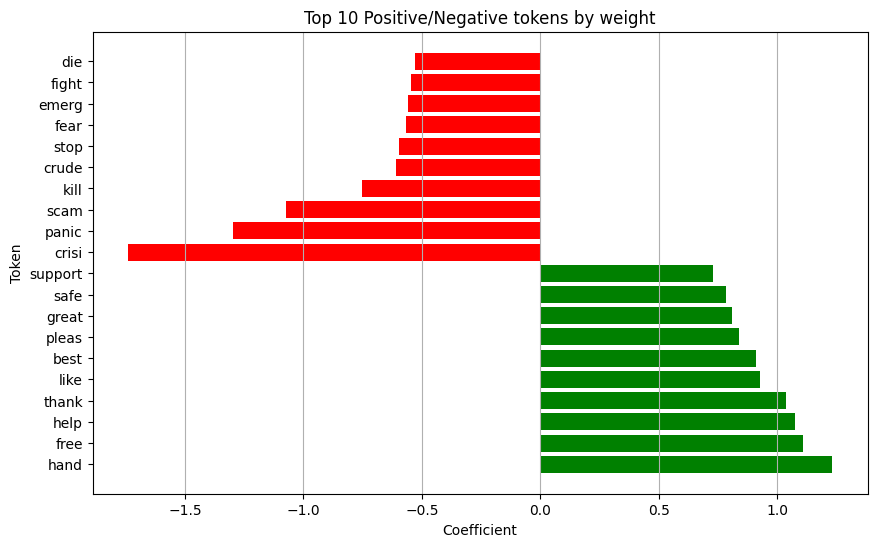

In [41]:
from sklearn.preprocessing import StandardScaler
train_vec = cv_df.fit_transform(train['OriginalTweet'])
test_vec=cv_df.transform(test['OriginalTweet'])
scaler = StandardScaler(with_mean=False)
train_scaled = scaler.fit_transform(train_vec)
test_scaled=scaler.transform(test_vec)

model = LogisticRegression(max_iter=1000)
model.fit(train_scaled, y_train)
y_pred_train = model.predict(train_scaled)
y_pred_test= model.predict(test_scaled)
print("Accuracy после скалирования:",accuracy_score(y_train, y_pred_train), accuracy_score(y_test, y_pred_test) )

vocab = cv_df.get_feature_names_out()
coefs = model.coef_[0]
top_pos = np.argsort(coefs)[-10:][::-1]
top_neg = np.argsort(coefs)[:10]
df_weights = pd.DataFrame({
    'token': [vocab[i] for i in list(top_pos) + list(top_neg)],
    'weight': np.concatenate([coefs[top_pos], coefs[top_neg]]),
    'type': ['positive']*10 + ['negative']*10
})


plt.figure(figsize=(10, 6))
colors = ['green' if t == 'positive' else 'red' for t in df_weights['type']]
plt.barh(df_weights['token'], df_weights['weight'], color=colors)
plt.title('Top 10 Positive/Negative tokens by weight')
plt.xlabel('Coefficient')
plt.ylabel('Token')
plt.grid(axis='x')
plt.show()

**Ответ:** Качество осталось почти таким же после скалирования данных. Среди отрицательных слов в основном слова, связанные с кризисом, паникой, убийствами и тому подобное, а в положительных словах в основном слова, связанные со свободой, помощью, блягодарностью и так далее. Притом вес у отрицательных по модулю больше, чем у положительных.

## Задание 7 Другие признаки (1.5 балла)

Мы были сконцентрированы на работе с текстами твиттов и не использовали другие признаки - имена пользователя, дату и местоположение

Изучите признаки UserName и ScreenName. полезны ли они? Если полезны, то закодируйте их, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

In [42]:
print(len(train),train['UserName'].nunique(),
train['ScreenName'].nunique())# -- YOUR CODE HERE --

23410 23410 23410


**Ответ:** Очевидно нет, так как среди них все значения уникальные (то есть они не влияют на обучение модели так же, как айдишники -- никак).

Изучите признак TweetAt в обучающей выборке: преобразуйте его к типу datetime и нарисуйте его гистограмму с разделением по цвету на основе целевой переменной. Полезен ли он? Если полезен, то закодируйте его, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

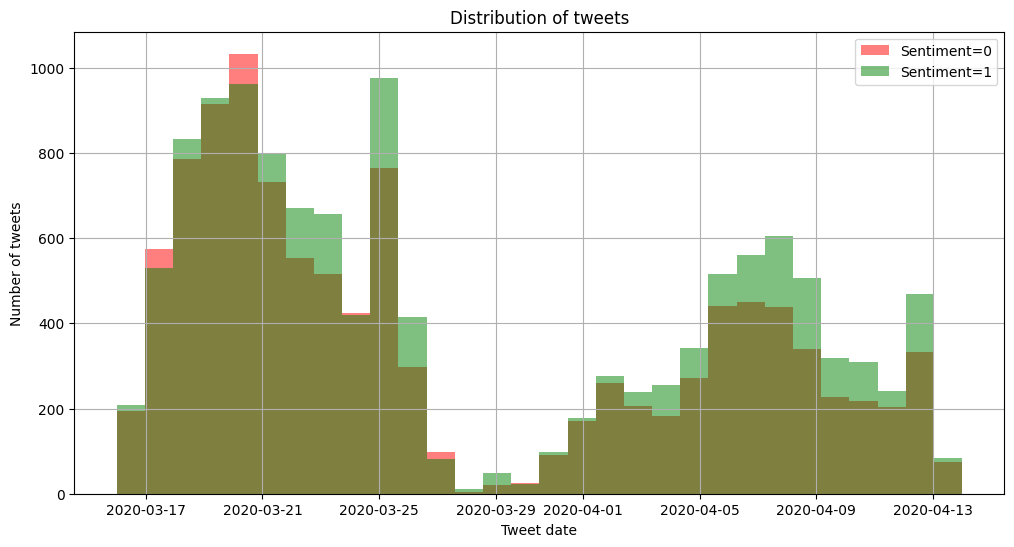

In [43]:
train['TweetAt']=pd.to_datetime(train['TweetAt'], format='%d-%m-%Y')
plt.figure(figsize=(12, 6))
for sentiment, color in zip([0, 1], ['red', 'green']):
    subset = train[train['Sentiment'] == sentiment]
    plt.hist(subset['TweetAt'], bins=30, color=color, alpha=0.5,
             label=f'Sentiment={sentiment}')
plt.xlabel('Tweet date')
plt.ylabel('Number of tweets')
plt.title('Distribution of tweets')
plt.legend()
plt.grid()
plt.show()# -- YOUR CODE HERE --

**Ответ:** Видим, что в целом хороших твитов постят больше, чем отрицательных. Также можно заметить, что твиты распределены неравномерно по месяцам (наверное, это связано с тем, что в некоторые месяцы происходили какие-то глобальные события, однако по дате модель не сможет сделать такой вывод), однако не выделяются какие-то временные промежутки, когда значительно преобладает один тип тональности.  Так что, я бы сказала, что нет явной временной зависимости количества твитов от времени, соответственно, не стоит его добавлять.



Поработайте с признаком Location в обучающей выборке. Сколько уникальных значений?

In [44]:
train['Location'].nunique()

7949

Постройте гистограмму топ-10 по популярности местоположений (исключая Unknown)

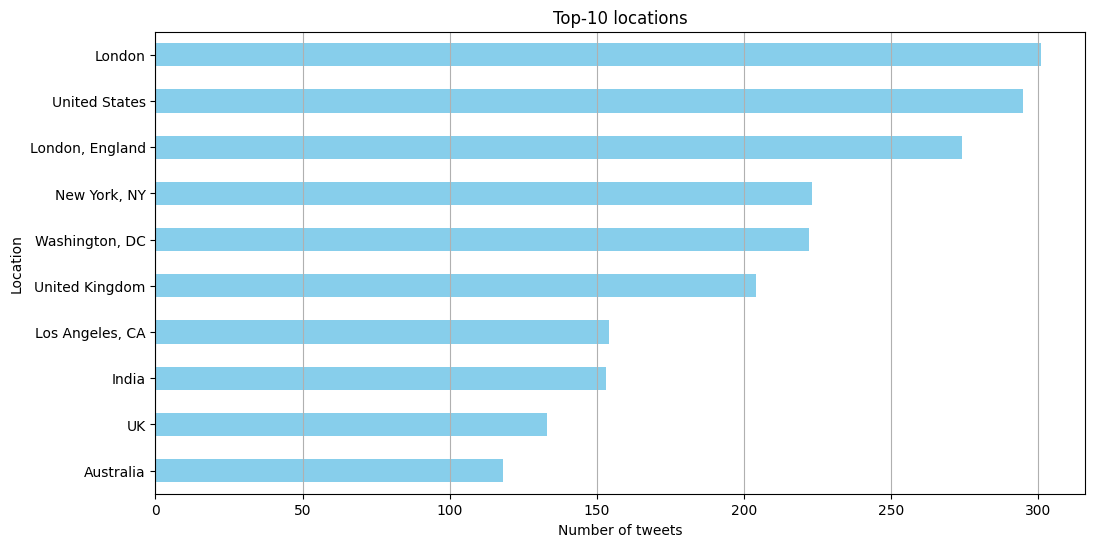

In [45]:
locations = train[train['Location'].isin(['Unknown', '']) == False]
top_locations = locations['Location'].value_counts().head(10)
plt.figure(figsize=(12, 6))
top_locations.sort_values().plot(kind='barh', color='skyblue')
plt.title('Top-10 locations')
plt.xlabel('Number of tweets')
plt.ylabel('Location')
plt.grid(axis='x')
plt.show()# -- YOUR CODE HERE --

Видно, что многие местоположения включают в себя более точное название места, чем другие (Например, у некоторых стоит London, UK; а у некоторых просто UK или United Kingdom).

Создайте новый признак WiderLocation, который содержит самое широкое местоположение (например, из London, UK должно получиться UK). Сколько уникальных категорий теперь? Постройте аналогичную гистограмму.

4766


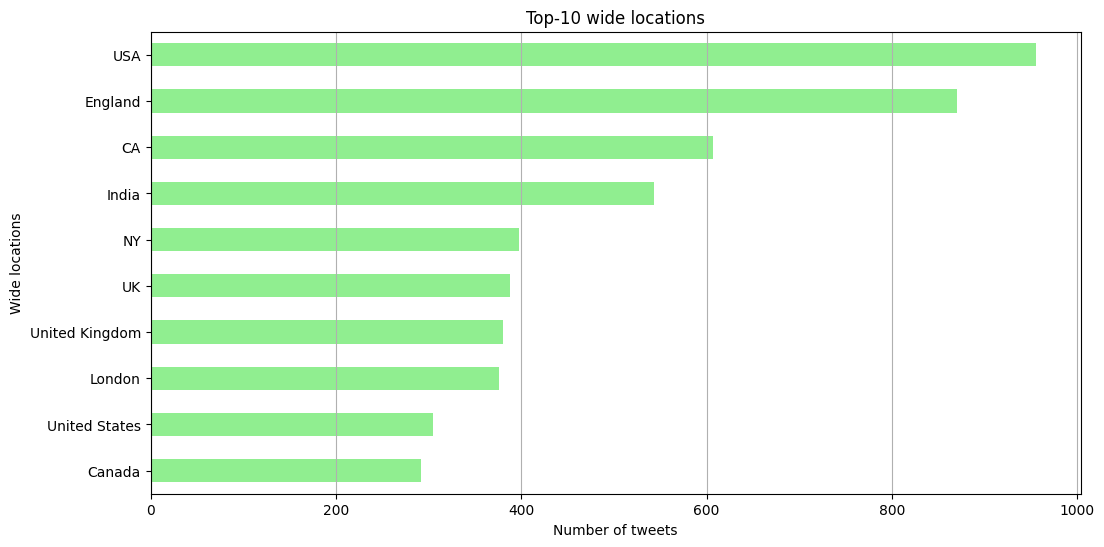

In [46]:
def get_location(loc):
    if pd.isna(loc) or loc in ['Unknown', '']:
        return 'Unknown'
    parts = [p.strip() for p in loc.split(',')]
    return parts[-1] if len(parts) > 1 else loc
train['WiderLocation'] = train['Location'].apply(get_location)
test['WiderLocation']=test['Location'].apply(get_location)
print(train['WiderLocation'].nunique())


known_wide = train[train['WiderLocation'] != 'Unknown']
top_wide_locations = known_wide['WiderLocation'].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_wide_locations.sort_values().plot(kind='barh', color='lightgreen')
plt.title('Top-10 wide locations')
plt.xlabel('Number of tweets')
plt.ylabel('Wide locations')
plt.grid(axis='x')
plt.show()# -- YOUR CODE HERE --

Закодируйте признак WiderLocation с помощью OHE таким образом, чтобы создались только столбцы для местоположений, которые встречаются более одного раза. Сколько таких значений?


In [47]:
from sklearn.preprocessing import OneHotEncoder
location_counts= train['WiderLocation'].value_counts()
categories=location_counts[location_counts>1].index.tolist()
ohe= OneHotEncoder(categories=[categories],sparse_output=True, handle_unknown='ignore')
locations_ohe_train= ohe.fit_transform(train[['WiderLocation']])
locations_ohe_test=ohe.transform(test[['WiderLocation']])
print(len(categories))

1005


Добавьте этот признак к матрице отскалированных текстовых признаков, обучите логистическую регрессию, замерьте качество. Как оно изменилось? Оказался ли признак полезным?


*Подсказка:* используйте параметр `categories` в энкодере.

In [48]:
from scipy.sparse import hstack
train_scaled=hstack([train_scaled,locations_ohe_train])
test_scaled=hstack([test_scaled,locations_ohe_test])
model = LogisticRegression(max_iter=1000)
model.fit(train_scaled, y_train)
y_pred_train = model.predict(train_scaled)
y_pred_test= model.predict(test_scaled)
print(accuracy_score(y_train, y_pred_train),accuracy_score(y_test, y_pred_test))# -- YOUR CODE HERE --

0.9453225117471166 0.8443292804464819


**Ответ:** Качество осталось примерно таким же, так что признак не кажется мне полезным.